<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_053_shap_explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 53/365 — SHAP
## Why did the model make this particular prediction?

Yesterday we learned **Permutation Feature Importance**, which answers a global question:

> Which features does the model rely on overall?

Today we go one step deeper:

**Why did the model make this prediction for this particular row?**

That is where **SHAP — SHapley Additive exPlanations** comes in.

Conceptually:

`Prediction = Baseline + Feature Contributions`


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

try:
    import shap
except ImportError:
    raise ImportError("Install SHAP once with: pip install shap")


## 1. Load a real dataset


In [2]:
data=load_breast_cancer(as_frame=True)
X=data.data
y=data.target

X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Dataset shape:",X.shape)
print("Classes:",data.target_names)


Dataset shape: (569, 30)
Classes: ['malignant' 'benign']


## 2. Train a Random Forest


In [3]:
model=RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train,y_train)

test_accuracy=accuracy_score(
    y_test,
    model.predict(X_test)
)

print("Test Accuracy:",round(test_accuracy,3))


Test Accuracy: 0.958


## 3. Create SHAP explanations

We explain only a sample of the test set to keep the notebook lightweight.


In [4]:
sample=X_test.iloc[:100].copy()

background=X_train.sample(
    min(100,len(X_train)),
    random_state=42
)

explainer=shap.Explainer(
    model,
    background
)

shap_values=explainer(sample)

print("SHAP values shape:",shap_values.values.shape)


SHAP values shape: (100, 30, 2)


## 4. Select one class when needed

Binary classifiers may return SHAP values for both classes.


In [5]:
def select_positive_class(explanation):
    values=explanation.values

    if values.ndim==3:
        return shap.Explanation(
            values=values[:,:,1],
            base_values=explanation.base_values[:,1],
            data=explanation.data,
            feature_names=explanation.feature_names
        )

    return explanation

positive_shap=select_positive_class(shap_values)


## 5. Global SHAP importance

This answers:

> Which features tend to move predictions the most across many observations?


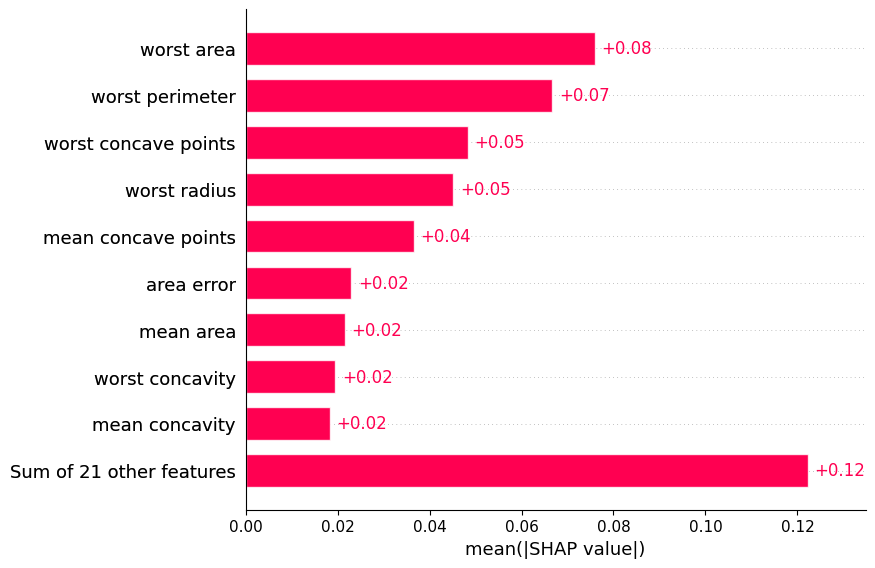

In [6]:
shap.plots.bar(
    positive_shap,
    max_display=10,
    show=True
)


## 6. Explain one individual prediction


In [7]:
row_number=0

row=sample.iloc[[row_number]]
prediction=model.predict(row)[0]
probability=model.predict_proba(row)[0]

print("Predicted class:",data.target_names[prediction])
print(
    "Class probabilities:",
    dict(zip(data.target_names,np.round(probability,3)))
)


Predicted class: benign
Class probabilities: {np.str_('malignant'): np.float64(0.01), np.str_('benign'): np.float64(0.99)}


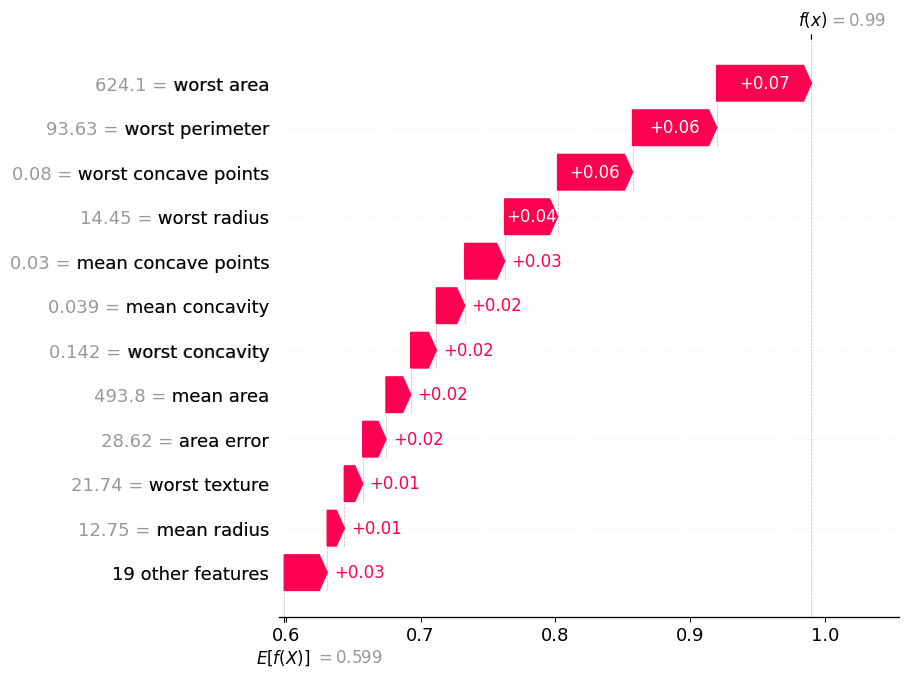

In [8]:
shap.plots.waterfall(
    positive_shap[row_number],
    max_display=12,
    show=True
)


## 7. How to read a SHAP waterfall plot

The plot starts from a **baseline model output**.

Each feature then pushes the model output higher or lower until the final prediction is reached.

That means we can move from:

> "This feature is important overall."

to:

> "For this specific prediction, these features pushed the model in this direction."


## 8. Permutation Importance vs SHAP

### Permutation Importance
Answers:

**Which features matter to overall predictive performance?**

Method:
- shuffle one feature
- measure the performance drop

### SHAP
Answers:

**How did individual features contribute to a prediction?**

SHAP can also be aggregated across many rows to give a global view.

The two methods are complementary.


## Enterprise intuition

Imagine a fraud model outputs:

`High Risk Probability = 0.87`

A reviewer naturally asks:

**Why?**

An explanation might show that the prediction was pushed upward by:

- unusually high transaction velocity
- a new device
- unusual location behaviour

while another feature, such as long account history, pushed the risk score downward.

That gives us much more context than simply saying:

**"The model predicted high risk."**

This kind of explanation can be useful in:

- fraud detection
- credit risk
- claims triage
- churn prediction
- pricing
- operational risk


## Important caveat

SHAP explains **the model's behaviour**.

It does not prove real-world causality.

A large SHAP contribution means:

> this feature strongly influenced the model's prediction

It does not automatically mean:

> changing this feature would cause the real-world outcome to change

Correlated features can also make attribution harder to interpret.


## What does this teach?

- Global feature importance and local explanation answer different questions.
- SHAP decomposes model outputs into feature contributions.
- Waterfall plots help explain individual predictions.
- SHAP values can also be aggregated for global understanding.
- SHAP explains model behaviour, not causality.
- Interpretability can help with debugging, review, monitoring, and stakeholder communication.

> **Prediction tells us what the model decided. SHAP helps us inspect what pushed the model toward that decision.**


## References

- https://shap.readthedocs.io/en/latest/
- https://arxiv.org/abs/1705.07874
- https://shap.readthedocs.io/en/latest/api.html
- https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html
